# 04 — Classification

Six classifiers, each representing a different idea of what makes two activity
traces similar:

| Model | What it looks at |
| :--- | :--- |
| k-NN (Euclidean) | the raw 400-number vector, point by point |
| k-NN (DTW) | the same shape, allowing it to drift in time |
| RDST | which short shapelets appear in the series |
| MiniRocket | responses to 10,000 fixed convolution kernels |
| MultiRocket-Hydra | the same idea, with several kernel families |
| PULSAR | pooled statistics of random sub-intervals |

**Why Macro F1 and not accuracy.** Two thirds of the children are class 0, so a
model that always guesses "Healthy" scores 66.6% accuracy while finding nobody
at risk. Macro F1 weights both classes equally, so ignoring the minority class
is penalised properly.

Only k-NN (Euclidean) is hyperparameter-tuned. The other five run at their
published defaults, because tuning a DTW or shapelet model over 3,549 subjects
costs hours per study for a fraction of a point of F1.

Equivalent to: `python main.py --stage classify`

In [1]:
# Make the project's src/ package importable from inside notebooks/.
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

from src.metrics import print_model_comparison, print_naive_baseline
from src.models import (add_jitter, extract_pulsar_features, flatten_channels,
                        run_knn_dtw, run_knn_euclidean, run_minirocket,
                        run_multirocket_hydra, run_pulsar, run_rdst)
from src.utils import load_prepared_arrays, select_model_channels

## 1. Load and reshape

Three views of the same data are needed:

- **3-D** `(subjects, channels, timesteps)` for the time-series libraries.
- **2-D flattened** `(subjects, 400)` for the plain scikit-learn estimators.
- **Jittered 3-D** for the aeon classifiers — `RDSTClassifier` aborts with a
  fatal `ValueError (std <= 1e-07)` on a completely flat channel, so Gaussian
  noise of sigma = 1e-6 is added. That sits far below the resolution of the
  normalised signal but satisfies the internal variance check.

Scaling is *not* applied here: each model that needs it carries a
`StandardScaler` inside its own pipeline, so it is refitted within every
cross-validation fold rather than once over all the data.

In [2]:
X_train_raw, X_test_raw, y_train, y_test = load_prepared_arrays()

X_train = select_model_channels(X_train_raw)
X_test = select_model_channels(X_test_raw)

X_train_flat = flatten_channels(X_train)
X_test_flat = flatten_channels(X_test)

X_train_jittered, X_test_jittered = add_jitter(X_train, X_test)

print(f"3D shape:        {X_train.shape}")
print(f"Flattened shape: {X_train_flat.shape}")

3D shape:        (3549, 2, 200)
Flattened shape: (3549, 400)


## 2. The number to beat

Always guessing the majority class. Any model that does not clearly exceed this
has learned nothing useful.

In [3]:
print_naive_baseline(y_train)

Class 0: 2365 subjects (66.64%)
Class 1: 1184 subjects (33.36%)

Your Naive Benchmark Accuracy is: 66.64%


np.float64(66.6384897154128)

## 3. Model 1 — k-NN with Euclidean distance

The simplest possible baseline: compare two children by lining their activity
traces up point for point. It has no notion that the same routine an hour later
is still the same routine — exactly the weakness the DTW version fixes.

This is the one model tuned with Optuna (10 trials, 4-fold CV on Macro F1).
`weights='distance'` lets closer neighbours count for more.

[I 2026-08-06 12:38:26,853] A new study created in memory with name: no-name-580b90fe-d47c-4444-bcc0-6521ecee836f
[I 2026-08-06 12:38:27,004] Trial 0 finished with value: 0.5357344895556365 and parameters: {'n_neighbors': 13}. Best is trial 0 with value: 0.5357344895556365.
[I 2026-08-06 12:38:27,108] Trial 1 finished with value: 0.544835109190627 and parameters: {'n_neighbors': 11}. Best is trial 1 with value: 0.544835109190627.
[I 2026-08-06 12:38:27,206] Trial 2 finished with value: 0.544696468017182 and parameters: {'n_neighbors': 16}. Best is trial 1 with value: 0.544835109190627.
[I 2026-08-06 12:38:27,302] Trial 3 finished with value: 0.5612741176163218 and parameters: {'n_neighbors': 8}. Best is trial 3 with value: 0.5612741176163218.
[I 2026-08-06 12:38:27,409] Trial 4 finished with value: 0.5612741176163218 and parameters: {'n_neighbors': 8}. Best is trial 3 with value: 0.5612741176163218.
[I 2026-08-06 12:38:27,539] Trial 5 finished with value: 0.5577949112896439 and paramet

Best hyperparameters for KNN (Euclidean): {'n_neighbors': 8}

Cross-Validation Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.67      0.69      2365
           1       0.41      0.46      0.44      1184

    accuracy                           0.60      3549
   macro avg       0.56      0.57      0.56      3549
weighted avg       0.61      0.60      0.61      3549

=== Evaluation: KNN (Euclidean) ===
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.65      0.70       592
           1       0.45      0.56      0.50       296

    accuracy                           0.62       888
   macro avg       0.60      0.61      0.60       888
weighted avg       0.65      0.62      0.63       888



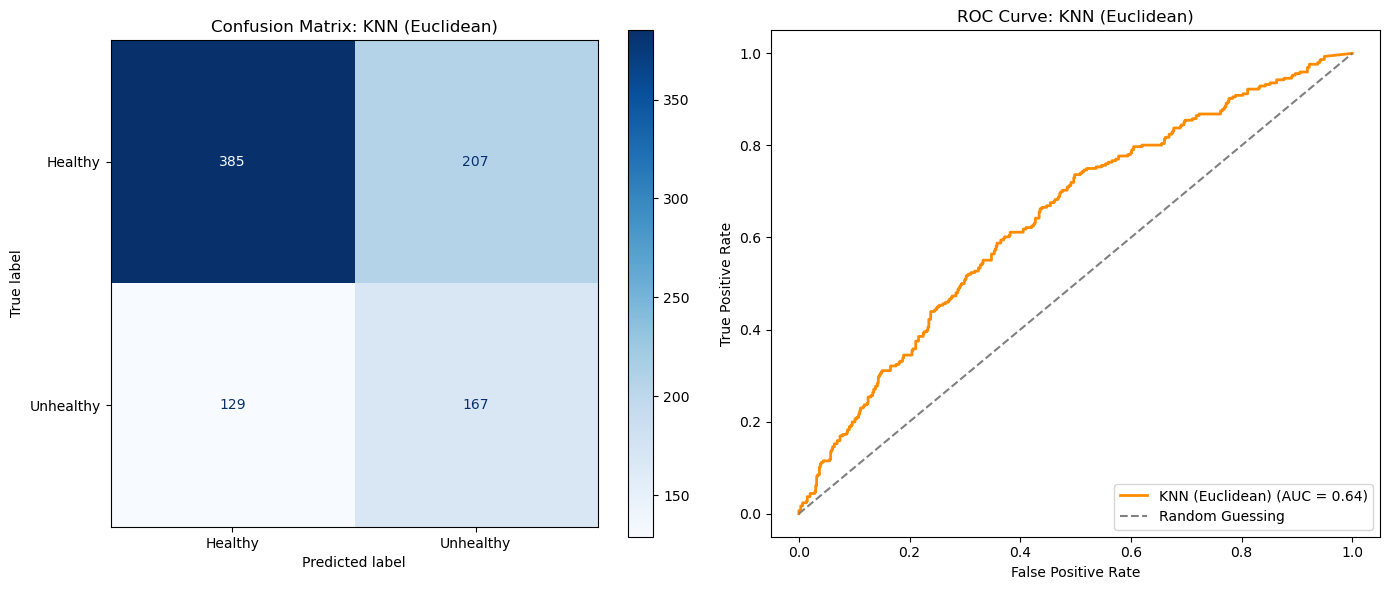

  [SUMMARY] KNN (Euclidean)
    Accuracy:          0.6216
    Macro F1:          0.5974
    Weighted F1:       0.6303
    AUC-ROC:           0.6428


=== KNN (Euclidean) — hyperparameter tuning result ===
  Best n_neighbors: 8
  Best CV Macro F1: 0.5613
  (Across 10 Optuna trials, 4-fold CV)


In [4]:
y_pred_euclidean, y_prob_euclidean = run_knn_euclidean(
    X_train_flat, y_train, X_test_flat, y_test)

## 4. Model 2 — k-NN with DTW

DTW stretches and compresses the time axis to find the best alignment, so two
children with the same routine shifted by an hour still count as similar.

**The Sakoe-Chiba band is not optional.** Unbounded DTW is quadratic per pair
and never finishes on thousands of multivariate samples. Restricting the
warping corridor to 10% of the series length (20 steps) makes it tractable.

From here on, every model tunes its **decision threshold** on out-of-fold
predictions rather than accepting the default 0.5. On an imbalanced problem
0.5 badly under-predicts the minority class; the sweep recovers recall on
class 1 at a small cost in precision. Doing it on cross-validation predictions
rather than the test set is what keeps the final score honest.

Skipping Optuna tuning for KNN with DTW due to computational cost. Using Sakoe-Chiba-bounded DTW (window=0.1).
Computing 4-fold cross-validation out-of-fold predictions...
Optimal CV Threshold Found: 0.100  (CV Macro F1: 0.569)

Cross-Validation Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

           0       0.71      0.71      0.71      2365
           1       0.43      0.43      0.43      1184

    accuracy                           0.62      3549
   macro avg       0.57      0.57      0.57      3549
weighted avg       0.62      0.62      0.62      3549

=== Evaluation: KNN (DTW) ===
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       592
           1       0.47      0.49      0.48       296

    accuracy                           0.64       888
   macro avg       0.60      0.61      0.60       888
weighted avg       0.65      0.64      0.65       888



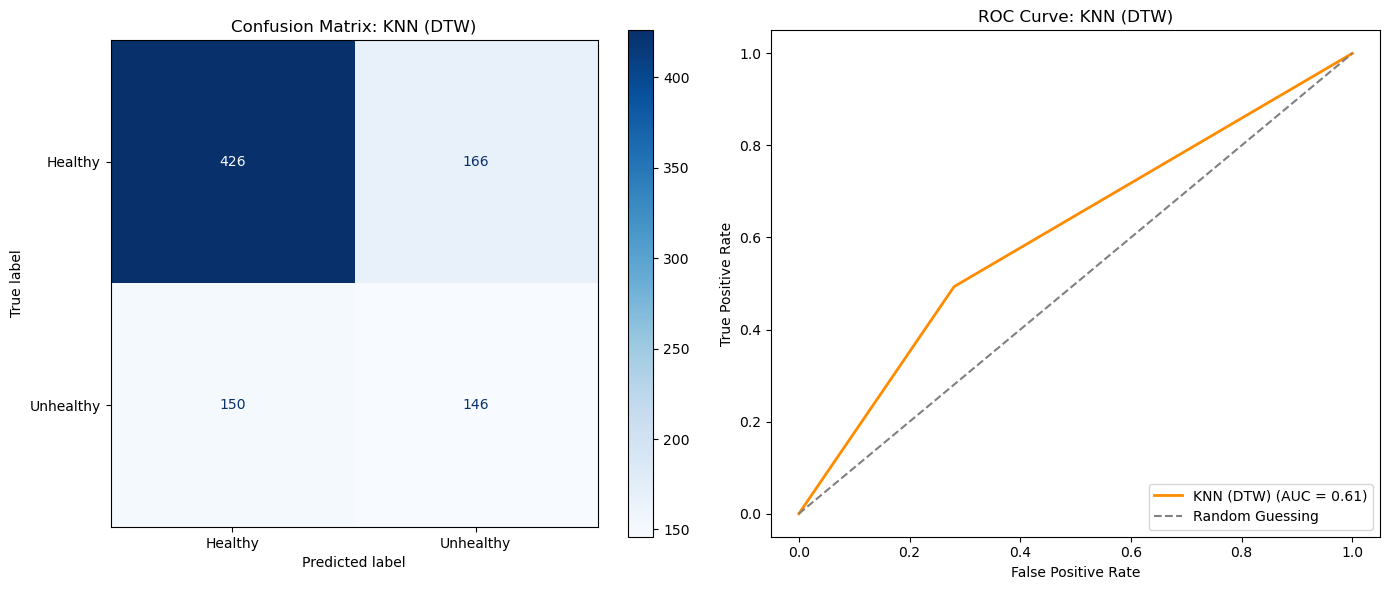

  [SUMMARY] KNN (DTW)
    Accuracy:          0.6441
    Macro F1:          0.6049
    Weighted F1:       0.6464
    AUC-ROC:           0.6064

=== KNN (DTW) — key parameters and final test results ===
  DTW window (Sakoe-Chiba): 10% of series length = 20 steps
  Optimal CV threshold:     0.100


In [5]:
y_pred_dtw, y_prob_dtw = run_knn_dtw(X_train, y_train, X_test, y_test)

## 5. Model 3 — RDST (Random Dilated Shapelet Transform)

RDST samples many short shapelets at random, with *dilation* — gaps between the
sampled points — so one short shapelet can describe a pattern spread over a
long stretch of time. Each series is then described by how well it matches each
shapelet.

This is the automated counterpart to the hand-picked search in notebook 03.

Skipping Optuna tuning for RDSTClassifier due to computational cost. Using default parameters + jitter fix.
Computing 4-fold cross-validation out-of-fold predictions...
Optimal CV Threshold Found: 0.100  (CV Macro F1: 0.541)

Cross-Validation Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

           0       0.70      0.92      0.79      2365
           1       0.54      0.20      0.29      1184

    accuracy                           0.68      3549
   macro avg       0.62      0.56      0.54      3549
weighted avg       0.64      0.68      0.62      3549

=== Evaluation: RDSTClassifier ===
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.92      0.81       592
           1       0.65      0.31      0.42       296

    accuracy                           0.72       888
   macro avg       0.69      0.61      0.62       888
weighted avg       0.70      0.72      0.68       888



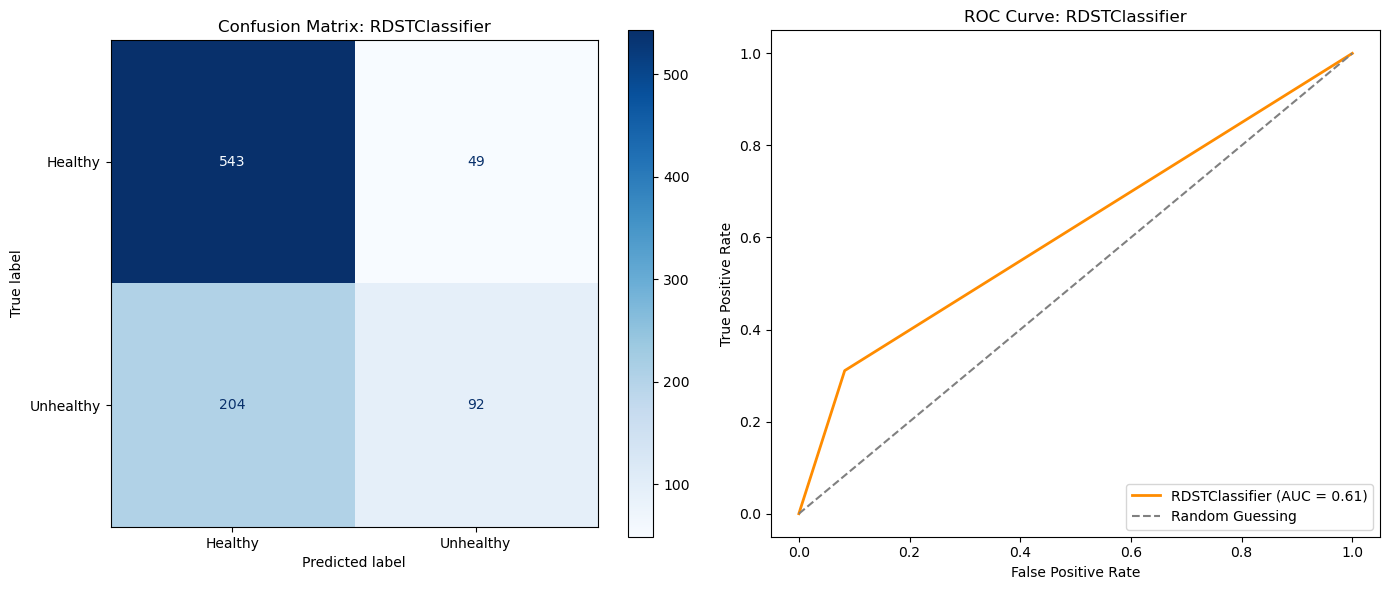

  [SUMMARY] RDSTClassifier
    Accuracy:          0.7151
    Macro F1:          0.6161
    Weighted F1:       0.6811
    AUC-ROC:           0.6140



In [6]:
y_pred_rdst, y_prob_rdst = run_rdst(X_train_jittered, y_train,
                                    X_test_jittered, y_test)

## 6. Model 4 — MiniRocket

MiniRocket convolves each series with 10,000 small **fixed** kernels and
summarises the responses. Because the kernels are not learned, the transform is
extremely fast, and a plain linear classifier on top is usually enough.

That linear classifier needs help: the ROCKET feature space is
high-dimensional, so the default 1,000 iterations leave it unconverged. Scaling
the features (without centring, to keep the sparse structure) and raising the
cap to 5,000 fixes it.

Skipping Optuna tuning for MiniRocket (default parameters are highly optimised + convergence fix applied).
Computing 4-fold cross-validation out-of-fold predictions...

Cross-Validation Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.74      0.72      2365
           1       0.43      0.40      0.42      1184

    accuracy                           0.62      3549
   macro avg       0.57      0.57      0.57      3549
weighted avg       0.62      0.62      0.62      3549

=== Evaluation: MiniRocket ===
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.69      0.70       592
           1       0.43      0.47      0.45       296

    accuracy                           0.61       888
   macro avg       0.58      0.58      0.58       888
weighted avg       0.62      0.61      0.62       888



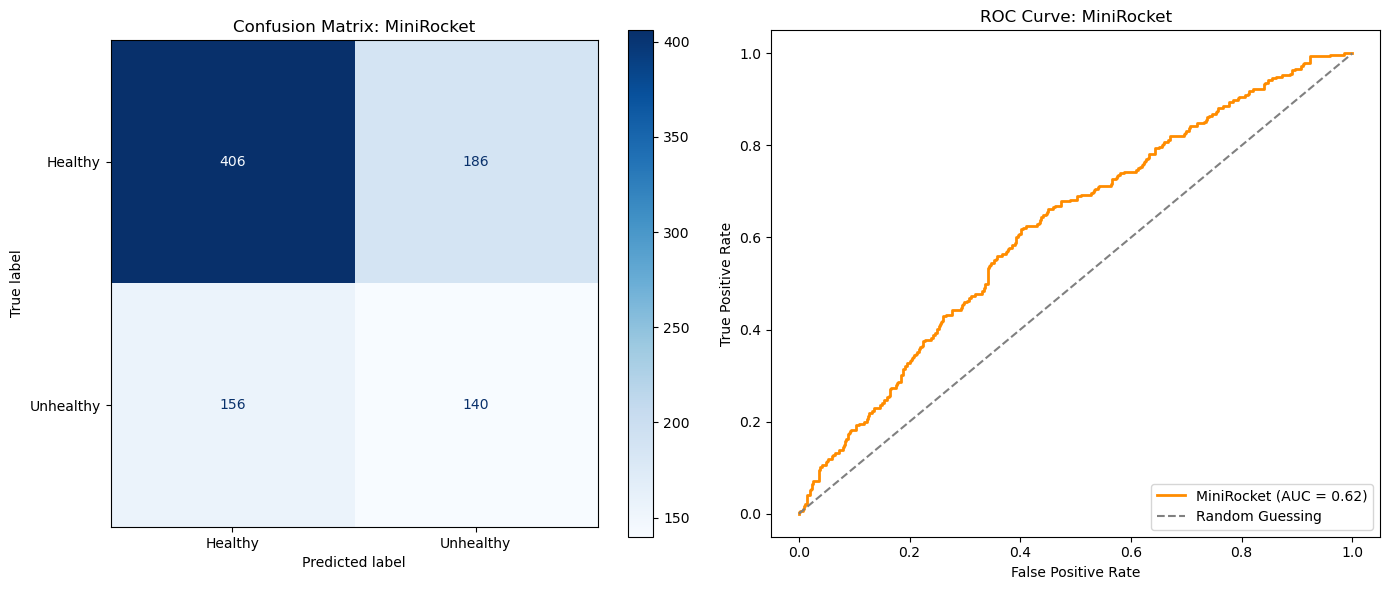

  [SUMMARY] MiniRocket
    Accuracy:          0.6149
    Macro F1:          0.5769
    Weighted F1:       0.6191
    AUC-ROC:           0.6228



In [7]:
y_pred_minirocket, y_prob_minirocket = run_minirocket(
    X_train_jittered, y_train, X_test_jittered, y_test)

## 7. Model 5 — MultiRocket-Hydra

Hydra combines two ideas: MultiRocket's several kernel families (capturing more
than just "did this kernel fire") and a dictionary-style count of which kernel
wins in each neighbourhood. It is one of the strongest general-purpose
time-series classifiers available, and it comes out on top on Macro F1 here.

Skipping Optuna tuning for MultiRocket Hydra due to computational cost.
Computing 4-fold cross-validation out-of-fold predictions...
Optimal CV Threshold Found: 0.100  (CV Macro F1: 0.571)

Cross-Validation Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

           0       0.71      0.80      0.75      2365
           1       0.46      0.34      0.39      1184

    accuracy                           0.65      3549
   macro avg       0.58      0.57      0.57      3549
weighted avg       0.62      0.65      0.63      3549

=== Evaluation: MultiRocket Hydra ===
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76       592
           1       0.50      0.41      0.45       296

    accuracy                           0.67       888
   macro avg       0.62      0.60      0.61       888
weighted avg       0.65      0.67      0.66       888



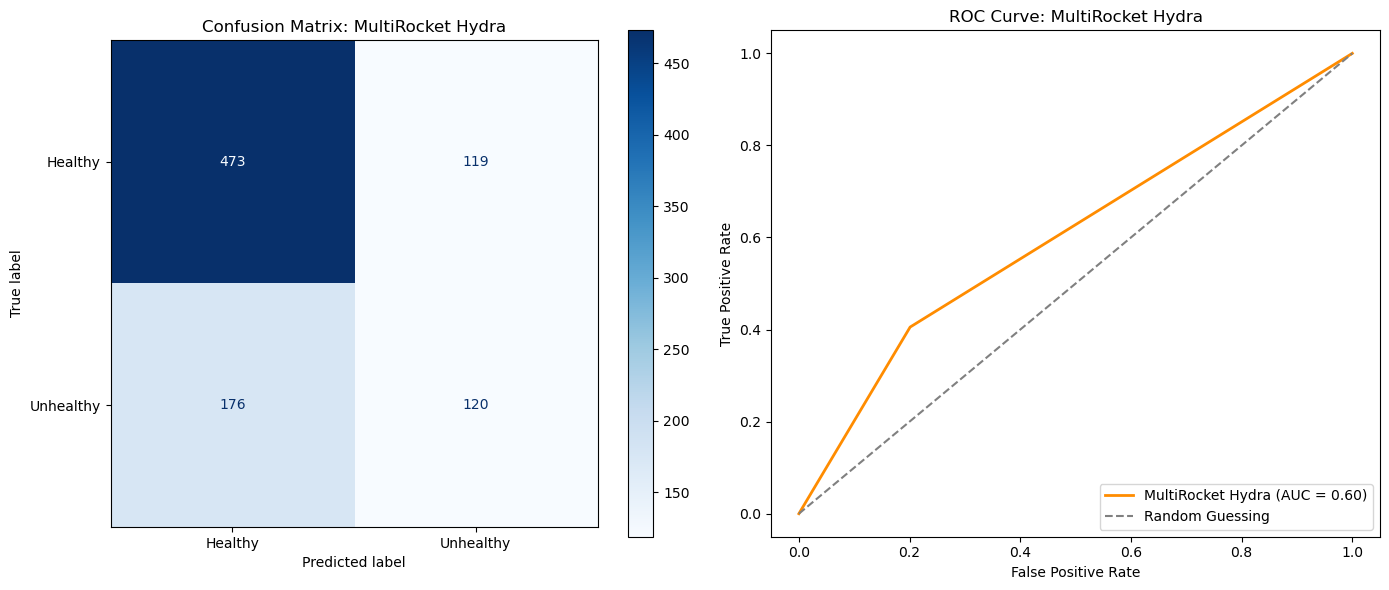

  [SUMMARY] MultiRocket Hydra
    Accuracy:          0.6678
    Macro F1:          0.6054
    Weighted F1:       0.6577
    AUC-ROC:           0.6022



In [8]:
y_pred_hydra, y_prob_hydra = run_multirocket_hydra(
    X_train_jittered, y_train, X_test_jittered, y_test)

## 8. Model 6 — Multivariate PULSAR (early fusion)

PULSAR converts a series into several representations (raw, derivative,
periodogram, autoregressive), computes simple statistics over randomly chosen
sub-intervals, and pools them at multiple depths. It is used here purely as a
**feature extractor** — its own internal ensemble is switched off.

**Early fusion**: rather than classifying each channel and combining votes
afterwards, the per-channel feature blocks are glued into one wide matrix so
the classifier can learn interactions *between* enmo and anglez directly. Each
extractor is fitted on training data only and then applied unchanged to test.

ExtraTrees suits the resulting very wide matrix: it picks split points at
random, which is fast and resists overfitting when features vastly outnumber
subjects. The calibration wrapper turns raw tree votes into probabilities the
threshold search can use.

In [9]:
train_features, test_features, extractors, per_channel_train = \
    extract_pulsar_features(X_train, y_train, X_test)

Initializing PULSAR Feature Extractors...
Extracting features from all channels for Multivariate PULSAR...
  -> Fitting extractor and transforming Channel 0/1...
  -> Fitting extractor and transforming Channel 1/1...

Multivariate Training Matrix Shape: (3549, 13296)
Extracting test features and evaluating...



Computing 4-fold cross-validation out-of-fold predictions...
Optimal CV Threshold Found: 0.390  (CV Macro F1: 0.644)

Cross-Validation Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

           0       0.76      0.79      0.77      2365
           1       0.54      0.49      0.51      1184

    accuracy                           0.69      3549
   macro avg       0.65      0.64      0.64      3549
weighted avg       0.68      0.69      0.69      3549

Fitting final multivariate classifier...
=== Evaluation: Multivariate PULSAR (Early Fusion) ===
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.91      0.80       592
           1       0.61      0.29      0.39       296

    accuracy                           0.70       888
   macro avg       0.66      0.60      0.60       888
weighted avg       0.68      0.70      0.67       888



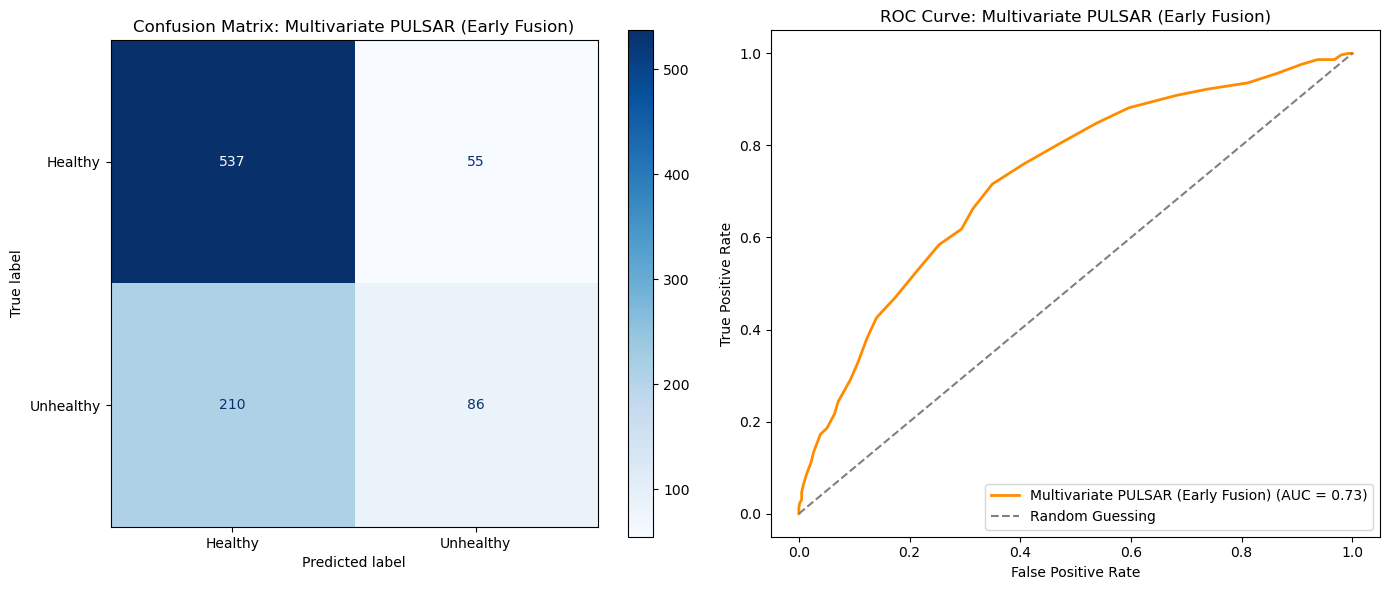

  [SUMMARY] Multivariate PULSAR (Early Fusion)
    Accuracy:          0.7016
    Macro F1:          0.5978
    Weighted F1:       0.6659
    AUC-ROC:           0.7295



In [10]:
y_pred_pulsar, y_prob_pulsar, pulsar_classifier = run_pulsar(
    train_features, test_features, y_train, y_test)

## 9. Explaining PULSAR

Two complementary views of the same fitted model:

- **Global** — which of the ~13,000 features does the forest rely on across all
  subjects?
- **Local (LORE)** — why was *this particular child* classified this way, and
  what would have had to differ for the answer to flip?

LORE generates a cloud of synthetic neighbours around one instance, asks the
black-box model to label them, and fits a shallow decision tree to that cloud.
The tree is only trusted locally, and its **fidelity** — how often it agrees
with the black box on the cloud — is reported, so a poor approximation is
visible rather than hidden.

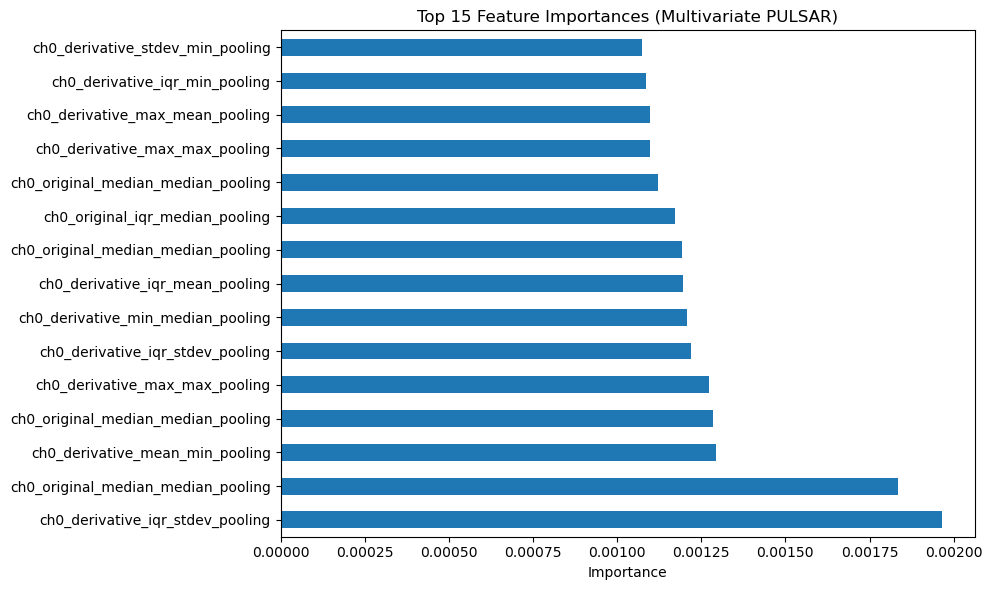

In [11]:
from src.explainability import (build_feature_names, lore_explain,
                                plot_feature_importances)

# The calibrated wrapper holds the actual forest; unwrap it to reach the
# feature importances and to get plain predictions for LORE.
forest = pulsar_classifier.calibrated_classifiers_[0].estimator
feature_names = build_feature_names(extractors, per_channel_train)

plot_feature_importances(forest, feature_names)

In [12]:
lore_explain(forest, train_features, test_features, feature_names)


[LORE] Local rule-based explanations

test idx=0 | ExtraTrees -> Healthy | local fidelity=0.994
Rule (-> class 0): IF ch0_original_iqr_stdev_pooling > -0.26 AND ch1_original_max_min_pooling > 0.01
Counter-factual (-> class 1): IF ch0_original_iqr_stdev_pooling <= -0.26 AND ch0_derivative_iqr_min_pooling <= -0.46 AND ch0_original_max_median_pooling > -0.39 AND ch1_original_slope_stdev_pooling <= 0.10

test idx=5 | ExtraTrees -> Healthy | local fidelity=1.000
Rule (-> class 0): IF ch1_periodogram_stdev_max_pooling <= 0.82 AND ch1_original_max_mean_pooling > 0.49
Counter-factual (-> class 1): IF ch1_periodogram_stdev_max_pooling > 0.82 AND ch0_original_iqr_mean_pooling > -0.69

test idx=10 | ExtraTrees -> Healthy | Neighbourhood generated only one class, cannot fit LORE tree.


## 10. Final comparison

In [13]:
results = [
    ("KNN-Euclidean", y_pred_euclidean, y_prob_euclidean),
    ("KNN-DTW", y_pred_dtw, y_prob_dtw),
    ("RDST", y_pred_rdst, y_prob_rdst),
    ("MiniRocket", y_pred_minirocket, y_prob_minirocket),
    ("MR-Hydra", y_pred_hydra, y_prob_hydra),
    ("PULSAR", y_pred_pulsar, y_prob_pulsar),
]

print_model_comparison(results, y_test)


=== FINAL MODEL COMPARISON — TEST SET ===
  Naive baseline (majority class accuracy): 0.6667

  Model              |   Accuracy |   Macro F1 |    AUC-ROC
  -------------------+------------+------------+-----------
  KNN-Euclidean      |     0.6216 |     0.5974 |     0.6428
  KNN-DTW            |     0.6441 |     0.6049 |     0.6064
  RDST               |     0.7151 |     0.6161 |     0.6140
  MiniRocket         |     0.6149 |     0.5769 |     0.6228
  MR-Hydra           |     0.6678 |     0.6054 |     0.6022
  PULSAR             |     0.7016 |     0.5978 |     0.7295


## What to take from this

Every model lands between 0.58 and 0.63 Macro F1, and only RDST and PULSAR beat
the 66.7% naive accuracy baseline — while doing so by predicting the majority
class more often, not by finding at-risk children better.

The honest summary: wrist actigraphy carries a *weak* signal about problematic
internet use. It is real — AUC of 0.73 for PULSAR is meaningfully above chance
— but nowhere near strong enough to screen individual children. Reduced
physical activity is a correlate, not a marker.